In [2]:
import numpy as np
import cirq

# 01 Cirq Basics

Goal: learn qubits, gates, operations, circuits, measurements, simulators, and shots.

In [14]:
#Hello world
qubit = cirq.GridQubit(0,0)

# creating a ciruit
circuit_exp = cirq.Circuit(cirq.X(qubit) ** 0.5, cirq.measure(qubit, key='m'))
print(circuit_exp)

print("Simulating several times")
simulator = cirq.Simulator()
results = simulator.run(circuit, repetitions= 20)
print("Resuls")
print(results)


(0, 0): ───X^0.5───M('m')───
Simulating several times
Resuls
m=10100100101100000101, 10100100101100000101


Quantum registers

In [24]:
print("Naming qubits")
q0 = cirq.NamedQubit('qubit0') #it follows lexicographic order qubit1 is before qubit22.
print("Range qubits")
q_line = cirq.LineQubit(2) + 1 - 1#qubits can be increased or decrease by integers
print("Grid qubits")
q_line = cirq.GridQubit(4,5) #define the rectangular lattice of qubits
q_line = cirq.GridQubit.square(4) #define the square lattice of qubits

print('')
print('Uploading devices directly for more realisty connectivity problems')
import cirq_google
import networkx as nx
my_device = cirq_google.Sycamore
print(my_device)


Naming qubits
Range qubits
Grid qubits

Uploading devices directly for more realisty connectivity problems
                                             (0, 5)───(0, 6)
                                             │        │
                                             │        │
                                    (1, 4)───(1, 5)───(1, 6)───(1, 7)
                                    │        │        │        │
                                    │        │        │        │
                           (2, 3)───(2, 4)───(2, 5)───(2, 6)───(2, 7)───(2, 8)
                           │        │        │        │        │        │
                           │        │        │        │        │        │
                  (3, 2)───(3, 3)───(3, 4)───(3, 5)───(3, 6)───(3, 7)───(3, 8)───(3, 9)
                  │        │        │        │        │        │        │        │
                  │        │        │        │        │        │        │        │
         (4, 1)───(4, 2)───(4, 3)───(4,

In [30]:
print("the actual connectivity might invalidade some 2 qubit gates")
print("Validade method run across gates and errors in this direction")
op1=cirq.H(cirq.GridQubit(6,8))

try:  
    my_device.validate_operation(op1)
except Exception as e:
    print(e) 

the actual connectivity might invalidade some 2 qubit gates
Validade method run across gates and errors in this direction
Qubit not on device: cirq.GridQubit(6, 8).


## Operation and gates!

gates can be applied to qubits, operation is when you apply the gate. Both are immutable objs. 

In [5]:
import cirq 
import numpy as np
q0 = cirq.NamedQubit("q0")
q1 = cirq.NamedQubit("q1")
q2 = cirq.NamedQubit("q2")

print("Gate Hadamard")
cirq.H
print("Hadamard operation ")
cirq.H(cirq.GridQubit(1,1))

print()
print("Possible 1 qubti gates")
display(cirq.H, cirq.X, cirq.Y, cirq.Z, cirq.T, cirq.S)
display(cirq.rx(np.pi/2), cirq.rz(np.pi/2), cirq.ry(np.pi/2)) 
print("Like X,Y,Z evolution exp(i pi t/2)")
display(cirq.HPowGate(exponent=2.), cirq.XPowGate(exponent=2.), cirq.YPowGate(exponent=2.), cirq.ZPowGate(exponent=2.))
print("2 plane rotations XY, like z(-p)--X(t)--Z(p)")
display(cirq.PhasedXPowGate(exponent=2., phase_exponent=1.))
print("Aritimetics works like square roots cirq.X **0.5")
print("Making controlled virsion of gates")
display(cirq.X.controlled()) # Gate controlled
display(cirq.X(cirq.GridQubit(1,1)).controlled_by(cirq.GridQubit(1,2))) # Controlled operation


print()
print()
print("2 qubit Gates")
display(cirq.unitary(cirq.CNOT))
display(cirq.CZ(q0,q1), cirq.CZPowGate(exponent=1.)) #q0 is the control
display(cirq.CNOT(q0,q1), cirq.SWAP(q0,q1), cirq.ISWAP(q0,q1))
display(cirq.XX(q0,q1),cirq.YY(q0,q1),cirq.ZZ(q0,q1))
print("Uself 2 qubit gate with 6 parameters because it is natively performed on hardware")
display(cirq.unitary(cirq.FSimGate(theta=0.5, phi=0.5)))

print()
print()
print("Especial Gates")
print("Unitary matrix from numpy")
cirq.MatrixGate(np.array([[1, 0], [0, 1]]))(q0)
print("Wait matrix ")
display(cirq.WaitGate(cirq.Duration(millis=1000))(q0))

#display(cirq.WaitGate(cirq.Duration(seconds=1.0))) # Useful for T1 and T2 measurements 

display(cirq.TOFFOLI(q0,q1,q2)) 
display(cirq.CCNOT(q0,q1,q2))
display(cirq.FREDKIN(q0,q1,q2))
display(cirq.TwoQubitDiagonalGate)
display(cirq.ThreeQubitDiagonalGate)
display(cirq.QubitPermutationGate)

Gate Hadamard
Hadamard operation 

Possible 1 qubti gates


cirq.H

cirq.X

cirq.Y

cirq.Z

...

cirq.TOFFOLI(cirq.NamedQubit('q0'), cirq.NamedQubit('q1'), cirq.NamedQubit('q2'))

cirq.FREDKIN(cirq.NamedQubit('q0'), cirq.NamedQubit('q1'), cirq.NamedQubit('q2'))

cirq.ops.two_qubit_diagonal_gate.TwoQubitDiagonalGate

cirq.ops.three_qubit_gates.ThreeQubitDiagonalGate

cirq.ops.permutation_gate.QubitPermutationGate

In [ ]:
print("Custom gate")

class RationalGate(cirq.Gate):
    def _num_qubits_(self) -> int:
        return 1
    def _unitary_(self):
        return np.array([3/5,  4/5], [-4/5, 3/5])
    def __str__(self):
        return 'ζ'
    

a = cirq.NamedQubit('a')
rg = RationalGate()
print(cirq.Circuit(rg(a)))
print("Such gates requires _apply_unitary_ for performance")

Custom gate
a: ───ζ───


## Bulding circuits

Moments are a collection of operations (vertical line of the circuit)

In [20]:
qubits = cirq.LineQubit.range(3)
circuit = cirq.Circuit()

for j in range(3):
    circuit.append(cirq.H(qubits[j]))
print(circuit)

print()
print("Controlling the moments")
print(cirq.Circuit(cirq.Moment([cirq.H(q)]) for q in cirq.LineQubit.range(3)))

print()
print("Types of appending")
ops = [cirq.H(q) for q in cirq.LineQubit.range(3)]
circuit.append(ops)
print(circuit)

circuit.append(cirq.H(q) for q in cirq.LineQubit.range(3))
print(circuit)

print()
print("Initialized version")
print(cirq.Circuit(cirq.H(q) for q in cirq.LineQubit.range(3)))

0: ───H───

1: ───H───

2: ───H───

Controlling the moments
0: ───H───────────

1: ───────H───────

2: ───────────H───

Types of appending
0: ───H───H───

1: ───H───H───

2: ───H───H───
0: ───H───H───H───

1: ───H───H───H───

2: ───H───H───H───

Initialized version
0: ───H───

1: ───H───

2: ───H───


In [ ]:
qubits = cirq.LineQubit.range(7)
print(cirq.Circuit(cirq.ISWAP(q,q+1) for q in qubits))

0: ───iSwap───────────────────────────────────────────────────
      │
1: ───iSwap───iSwap───────────────────────────────────────────
              │
2: ───────────iSwap───iSwap───────────────────────────────────
                      │
3: ───────────────────iSwap───iSwap───────────────────────────
                              │
4: ───────────────────────────iSwap───iSwap───────────────────
                                      │
5: ───────────────────────────────────iSwap───iSwap───────────
                                              │
6: ───────────────────────────────────────────iSwap───iSwap───
                                                      │
7: ───────────────────────────────────────────────────iSwap───


### Device awareness

In [31]:
import cirq_google
Syc_dev = cirq_google.Sycamore
print(Syc_dev)

q0 = cirq.GridQubit(0,5)
q1 = cirq.GridQubit(0,6)
q2 = cirq.GridQubit(1,4)

#Creating Sycamore op. with adjancent qubit and non-adjacent qubits
adjacent_op = cirq_google.SYC(q0,q1)
nonadjacent_op = cirq_google.SYC(q0,q2)


# Running the circuit - No issues yet
circuit = cirq.Circuit()
circuit.append(adjacent_op)
print("Validating append for adjacent")
display(cirq_google.Sycamore.validate_circuit(circuit))

circuit.append(nonadjacent_op)
try:
    cirq_google.Sycamore.validate_circuit(circuit)
except ValueError as e:
    print(e)

                                             (0, 5)───(0, 6)
                                             │        │
                                             │        │
                                    (1, 4)───(1, 5)───(1, 6)───(1, 7)
                                    │        │        │        │
                                    │        │        │        │
                           (2, 3)───(2, 4)───(2, 5)───(2, 6)───(2, 7)───(2, 8)
                           │        │        │        │        │        │
                           │        │        │        │        │        │
                  (3, 2)───(3, 3)───(3, 4)───(3, 5)───(3, 6)───(3, 7)───(3, 8)───(3, 9)
                  │        │        │        │        │        │        │        │
                  │        │        │        │        │        │        │        │
         (4, 1)───(4, 2)───(4, 3)───(4, 4)───(4, 5)───(4, 6)───(4, 7)───(4, 8)───(4, 9)
         │        │        │        │        │        │   

None

Qubit pair is not valid on device: (cirq.GridQubit(0, 5), cirq.GridQubit(1, 4)).


Time of gates on a device

In [192]:
import cirq_google

op = cirq.X.on(cirq.GridQubit(5,5))
gate_time = cirq_google.Sycamore.metadata.gate_durations

for gate_family in gate_time:
    if op in gate_family:
        print(gate_time[gate_family])

25 ns


## Simulator (20 qubits limit)

simulate(): Classical circuit with wave function view. 

run(): Quantum circuit with just end results

In [35]:
q0 = cirq.NamedQubit("q0")
q1 = cirq.NamedQubit("q1")

Bell_circuit=cirq.Circuit()
Bell_circuit.append(cirq.H(q0))
Bell_circuit.append(cirq.CNOT(q0,q1))
print(Bell_circuit)

s = cirq.Simulator()
results = s.simulate(Bell_circuit)
print(results)

print()
print("Measuring")
Bell_circuit.append(cirq.measure(q0,q1, key='yfukdasos'))
print(Bell_circuit)
samples=s.run(Bell_circuit, repetitions=1000)

q0: ───H───@───
           │
q1: ───────X───
measurements: (no measurements)

qubits: (cirq.NamedQubit('q0'), cirq.NamedQubit('q1'))
output vector: 0.707|00⟩ + 0.707|11⟩

phase:
output vector: |⟩

Measuring
q0: ───H───@───M('yfukdasos')───
           │   │
q1: ───────X───M────────────────


In [36]:
samples.measurements["yfukdasos"] #yfukdasos any string
samples.data #panda table
counts = samples.histogram(key="yfukdasos")
display(counts)

Counter({3: 524, 0: 476})

## Virtual Machine Simulation 

Quantum harware device simualtion! 

Virtual Engine interface: run and verify same interface as the actual hardware.

noise models: tries to replicate realist noise in hardware.

This is important to figure out how to be less impacted by noise on your circuit. 

## Visualization

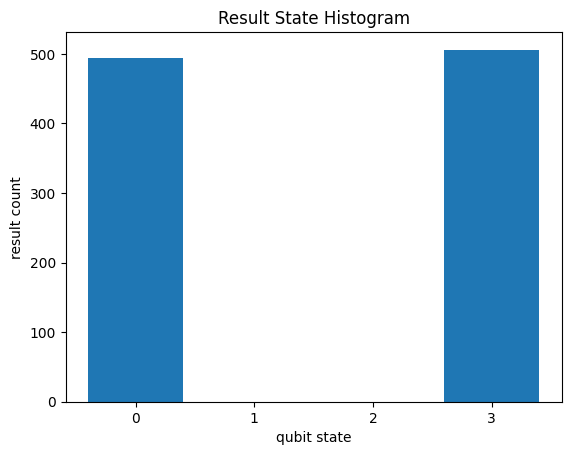

If the system is too sparse in 0 bits, we plot just nonzero


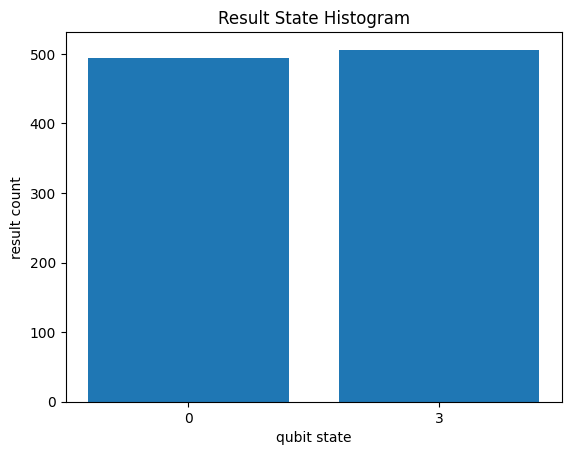

In [46]:
import matplotlib.pyplot as plt

cirq.plot_state_histogram(samples, plt.subplot())
plt.show()
print("If the system is too sparse in 0 bits, we plot just nonzero")
counts = samples.histogram(key='result')
cirq.plot_state_histogram(counts, plt.subplot())
plt.show()

<Axes: title={'center': 'Result State Histogram'}, xlabel='qubit state', ylabel='result count'>

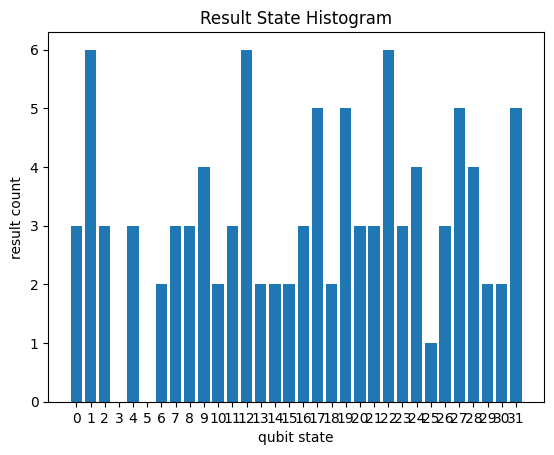

In [64]:
qubits = cirq.LineQubit.range(5)
circuit=cirq.Circuit()
circuit.append(cirq.H(q) for q in qubits)

s = cirq.Simulator()
circuit.append(cirq.measure(q) for q in qubits)
results= s.run(circuit, repetitions=100)

cirq.plot_state_histogram(results, plt.subplot())

pass function to histogram, like even or odd bits


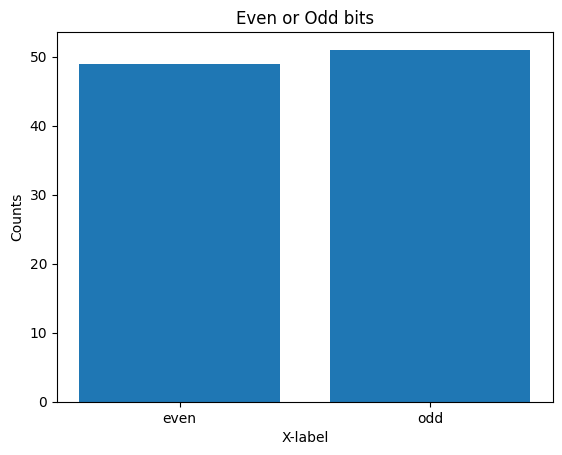

In [76]:
print("pass function to histogram, like even or odd bits")

def count_ones(bits):
    return 'even' if sum(bits) % 2 == 0 else 'odd'

q = cirq.LineQubit.range(9)
circuit = cirq.Circuit([cirq.H.on_each(*q), cirq.measure(*q, key='measure_all')])
result=cirq.Simulator().run(circuit, repetitions=100)

custom_histogram = result.histogram(key='measure_all', fold_func=count_ones)
_ = cirq.plot_state_histogram(
    custom_histogram,
    plt.subplot(),
    title='Even or Odd bits',
    xlabel='X-label',
    ylabel='Counts',
    #tick_label=binary_label(3),
    )

Text(0.5, 0, 'steps')

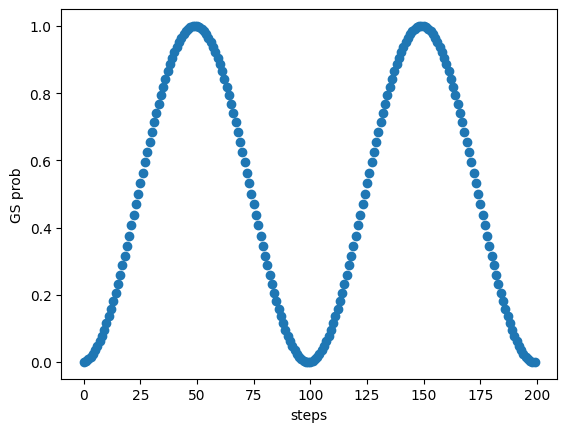

In [104]:
import matplotlib.pyplot as plt
q = cirq.LineQubit(1)

num_angles = 200
c = cirq.Circuit(cirq.Rx(rads= np.pi /50)(q) for theta in range(num_angles))

probs=[]
for step in s.simulate_moment_steps(c):
    prob = np.abs(step.state_vector(copy=True) ** 2)
    probs.append(1 - prob[0])

plt.plot(probs, "o")
plt.ylabel("GS prob")
plt.xlabel("steps")

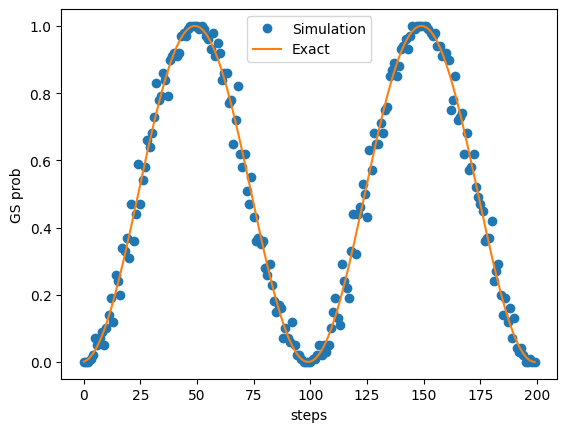

In [105]:
q = cirq.LineQubit(1)

num_angles = 200
c = cirq.Circuit(cirq.Rx(rads= np.pi /50)(q) for theta in range(num_angles))
repetitions=100
s_probs=[]
for step in s.simulate_moment_steps(c):
    samples = step.sample([q], repetitions=repetitions)
    prob = np.sum(samples, axis=0)[0] / repetitions
    s_probs.append(prob)

plt.plot(s_probs, "o", label="Simulation")
plt.plot(probs, "-", label="Exact")
plt.ylabel("GS prob")
plt.xlabel("steps")
plt.legend()

## Parameter sweep

Useful for variational algorithms to optimize a cost function. Possibilities:

    (i) cirq.Points: list of specific values (sequence of floats) 

    (ii) cirq.Linspace: from start to end parameter

    (iii) cirq.ListSweep: manually specified values for different symbols (list of dic)

    (iv) cirq.Zip and cirq.Product: list-wise sweep with zip or cartesian product sweep with Product

Simulating qubit under X^(t)
from  0 (off) to 1 (on) and back to 2 (off), because X^2 = I


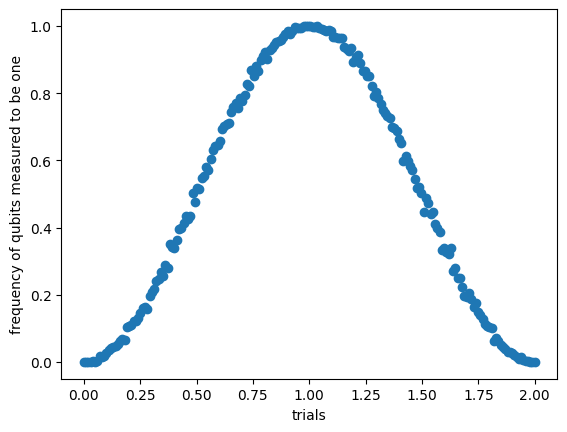

In [99]:
print("Simulating qubit under X^(t)")
print("from  0 (off) to 1 (on) and back to 2 (off), because X^2 = I")
import sympy

circuit = cirq.Circuit(cirq.X(q)**sympy.Symbol('t') for q in cirq.LineQubit.range(1))
circuit.append(cirq.measure(q, key='m') for q in cirq.LineQubit.range(1))

# Defining param_sweep
param_sweep = cirq.Linspace('t', start=0, stop=2, length=200)

s= cirq.Simulator()
trials = s.run_sweep(circuit, param_sweep, repetitions=1000)

x_data=[trial.params['t'] for trial in trials]
y_data=[trial.histogram(key='m')[1]/1000 for trial in trials]
plt.scatter('t', 'p', data={'t':x_data, 'p':y_data})
plt.xlabel("trials")
plt.ylabel("frequency of qubits measured to be one")
plt.show()

## Decomposing gates

In [111]:
print("Hadamard decomeposed in X and Y")
print(cirq.decompose(cirq.H(cirq.LineQubit(0))))
print()
print("Toffoli gate decomposed")
q1,q2,q3 = cirq.LineQubit.range(3)
print(cirq.Circuit(cirq.decompose(cirq.TOFFOLI(q1,q2,q3))))


Hadamard decomeposed in X and Y
[(cirq.Y**0.5).on(cirq.LineQubit(0)), cirq.XPowGate(global_shift=-0.25).on(cirq.LineQubit(0))]

Toffoli gate decomposed
0: ───T────────────────@─────────────────────────────────@─────────────────────────────@────────────────────────────@───────────────────────────────────────
                       │                                 │                             │                            │
1: ───T───────Y^-0.5───@───Y^0.5────@───T^-1────Y^-0.5───@────────Y^0.5───@───Y^-0.5───@──────Y^0.5────@───Y^-0.5───@──────Y^0.5────@───────────────────────
                                    │                                     │                            │                            │
2: ───Y^0.5───X────────T───Y^-0.5───@───Y^0.5───T────────Y^-0.5───────────@───Y^0.5────T^-1───Y^-0.5───@───Y^0.5────T^-1───Y^-0.5───@───Y^0.5───Y^0.5───X───


## Transformers

It modifies/manipulates circuits. For example, from defined 1 qubit gates, it can change to phasedXZ operation.

input circuit and output circuit. Useful to rewrite circuits from hardware constraits. For example, gate decomposition, qubit mapping, circuit optimization. All options can be found in 
https://github.com/quantumlib/Cirq/tree/main/cirq-core/cirq/transformers
some notable options are in https://quantumai.google/cirq/transform/transformers

In [121]:
q = cirq.GridQubit(1,1)
c = cirq.Circuit(cirq.X(q)**0.25, cirq.Y(q)**0.25, cirq.Z(q)**0.25 )
print(c)
c = cirq.merge_single_qubit_gates_to_phxz(c)
print(c)

(1, 1): ───X^0.25───Y^0.25───T───
(1, 1): ───PhXZ(a=0.304,x=0.333,z=0.142)───


In [125]:
print("Example of circuit optimizer pipeline")

def optimize_circuit(circuit, context=None, k=2):

    #Merge 2qubit connected components into circuit operations
    optimized_circuit = cirq.merge_k_qubit_unitaries(
        circuit, k=k, rewriter=lambda op: op.with_tags("merged"), context=context
    )

    #Drop close to identity op.
    optimized_circuit = cirq.drop_negligible_operations(optimized_circuit, context=context)

    #Decomposing components
    optimized_circuit = cirq.expand_composite(
            optimized_circuit, no_decomp=lambda op: "merged" not in op.tags, context=context
    )

    #Sync measurements to happen at the same moment
    optimized_circuit = cirq.synchronize_terminal_measurements(optimized_circuit, context=context)

    #Assert that circuit and optimized_circuit are the same
    cirq.testing.assert_circuits_with_terminal_measurements_are_equivalent(circuit, optimized_circuit)

    return optimized_circuit


q = cirq.LineQubit.range(3)
circuit = cirq.Circuit(
    cirq.H(q[1]),
    cirq.CNOT(*q[1:]),
    cirq.H(q[0]),
    cirq.CNOT(*q[:2]),
    cirq.H(q[1]),
    cirq.CZ(*q[:2]),
    cirq.H.on_each(*q[:2]),
    cirq.CNOT(q[2], q[0]),
    cirq.measure_each(*q),
)
print("Original Circuit:", circuit, sep="\n")
print("Optimized Circuit:", optimize_circuit(circuit), sep="\n")

Example of circuit optimizer pipeline
Original Circuit:
                              ┌──┐
0: ───H───────@───────@───H────X─────M───
              │       │        │
1: ───H───@───X───H───@───H────┼M────────
          │                    │
2: ───────X────────────────────@─────M───
                              └──┘
Optimized Circuit:
0: ───────────X───M───
              │
1: ───H───@───┼───M───
          │   │
2: ───────X───@───M───


We can have the log of the operations to look closely what the transformer is doing

In [126]:
context= cirq.TransformerContext(logger=cirq.TransformerLogger())
optimized_circuit = optimize_circuit(circuit, context)
context.logger.show()

Transformer-1: merge_k_qubit_unitaries
Initial Circuit:
                              ┌──┐
0: ───H───────@───────@───H────X─────M───
              │       │        │
1: ───H───@───X───H───@───H────┼M────────
          │                    │
2: ───────X────────────────────@─────M───
                              └──┘


Final Circuit:
                                                                            ┌───────────────────────┐
                                   [ 0: ───H───@───────@───H─── ]             [ 0: ───X─── ]
0: ────────────────────────────────[           │       │        ]─────────────[       │    ]────────────M───
                                   [ 1: ───────X───H───@───H─── ][merged]     [ 2: ───@─── ][merged]
                                   │                                          │
      [ 1: ───H───@─── ]           │                                          │
1: ───[           │    ]───────────#2────────────────────────────────────────M┼─────────────────────

We can tag for no-compile, which are ignored by the transformer. 

In [132]:
print("Example: Echo pulses to prevent dephasing in idling should be ignored")
c = cirq.Circuit(
    cirq.H(q[0]),
    cirq.CNOT(*q[:2]),
    [
        op.with_tags("spin_echoes") for op in [cirq.X(q[0]) ** 0.5, cirq.X(q[0]) ** -0.5]
    ], #echo pulse
    [cirq.CNOT(*q[1:]), cirq.CNOT(*q[1:])],
    [cirq.CNOT(*q[:2]), cirq.H(q[0])],
    cirq.measure_each(*q)
)
print("Original circuit: ", c, "\n", sep="\n")

print("Optimized without tags_to_ignore")
print(optimize_circuit(c, k=1), "\n")

print("Optimized with tags_to_ignore")
context= cirq.TransformerContext(tags_to_ignore=["spin_echoes"])
print(optimize_circuit(c, k=1, context=context), "\n")

Example: Echo pulses to prevent dephasing in idling should be ignored
Original circuit: 
0: ───H───@───X[spin_echoes]^0.5───X[spin_echoes]^-0.5───@───H───M───
          │                                              │
1: ───────X───@────────────────────@─────────────────────X───M───────
              │                    │
2: ───────────X────────────────────X─────────────────────M───────────


Optimized without tags_to_ignore
0: ───H───@───────────@───H───M───
          │           │
1: ───────X───@───@───X───────M───
              │   │
2: ───────────X───X───────────M─── 

Optimized with tags_to_ignore
0: ───H───@───X[spin_echoes]^0.5───X[spin_echoes]^-0.5───@───H───M───
          │                                              │
1: ───────X───@────────────────────@─────────────────────X───────M───
              │                    │
2: ───────────X────────────────────X─────────────────────────────M─── 



Usually sub_circuits are left as it is since transformers just modifies top-level op. However, if in context depp=True is applied, the sub circuits are also acted by the transformer. 

In [133]:
context = cirq.TransformerContext(tags_to_ignore=["spin_echoes"], deep=True)
print(optimize_circuit(c, k=1, context=context), "\n")

0: ───[ 0: ───H─── ][merged]───@───X[spin_echoes]^0.5───X[spin_echoes]^-0.5───@───[ 0: ───H─── ][merged]───M───
                               │                                              │
1: ────────────────────────────X───@────────────────────@─────────────────────X────────────────────────────M───
                                   │                    │
2: ────────────────────────────────X────────────────────X──────────────────────────────────────────────────M─── 



We can use target circuit in oder to compile NISQ circuits. They have for specific gates

In [ ]:
q = cirq.LineQubit.range(3)
circuit = cirq.Circuit(cirq.QuantumFourierTransformGate(3).on(*q), cirq.measure(*q))
print("Original circuit: ", circuit, "\n", sep="\n")

#“Compile this circuit into a form whose entangling gates are CZ-type gates.”
gateset = cirq.CZTargetGateset(allow_partial_czs=True) # partial gates ^0,5, ^0.75
cz_circuit=cirq.optimize_for_target_gateset(circuit, gateset=gateset)
cirq.testing.assert_circuits_with_terminal_measurements_are_equivalent(circuit, cz_circuit)
print("Circuit with CZ Target Gateset:", cz_circuit, "\n", sep="\n")

Original circuit: 
0: ───qft───M───
      │     │
1: ───#2────M───
      │     │
2: ───#3────M───


Circuit with CZ Target Gateset:
0: ───PhXZ(a=0.5,x=0.5,z=0)───@────────PhXZ(a=-1.0,x=1,z=0)──────────────PhXZ(a=0.5,x=-0.5,z=0)───@───PhXZ(a=0.5,x=0.5,z=0)────@───PhXZ(a=0.5,x=-0.5,z=0)───@────────PhXZ(a=0.5,x=0.5,z=-1)───M───
                              │                                                                   │                            │                            │                                 │
1: ───────────────────────────@^-0.5───PhXZ(a=-1,x=0.5,z=-0.5)───@────────────────────────────────┼────────────────────────────┼────────────────────────────┼─────────────────────────────────M───
                                                                 │                                │                            │                            │                                 │
2: ──────────────────────────────────────────────────────────────@^0.5───PhXZ(a=0.5,x=-0.5,z=0

## Insert strategies

We have considered just one-dim protocols, what about 2D? 

InsertStrategy how an operation is place for a given location. Locations is Moment in the circuit. 

Options:
    .EARLIEST (default) 
    .NEW
    .INLINE
    .NEW_THEN_INLINE (see if any of the qubits on that moment can be put it ealier)


In [36]:
q = cirq.LineQubit.range(3)
c = cirq.Circuit(
    cirq.CZ(q[0],q[1]), cirq.H(q[2])
)
c.append([cirq.H(q[0]), cirq.H(q[1]), cirq.CZ(q[1], q[2])], strategy=cirq.InsertStrategy.NEW)
c.append([cirq.H(q[0]), cirq.H(q[1]),cirq.H(q[0])], strategy=cirq.InsertStrategy.INLINE)
print(c)

0: ───@───H───────────H───H───
      │
1: ───@───────H───@───H───────
                  │
2: ───H───────────@───────────


## Noise

density matrix evolution $\rho \to \sum_k A_k \rho A_k^\dagger$

where $\sum_k A_k^\dagger A_k = I$ and $A_k$ is the Kraus operator. 

In [159]:
print("Depolarization channel")
a = cirq.NamedQubit('a')
c = cirq.Circuit(cirq.depolarize(0.2)(a), cirq.measure(a, key='m'))
print(c)

print()
print("Looking into Kraus matrices")
for i,kraus in enumerate(cirq.kraus(cirq.depolarize(0.2))):
    print(f"kraus operator {i} is: ", kraus, sep="\n", end="\n\n")

print("In Pauli basis ")
for i,kraus in enumerate(cirq.kraus(cirq.depolarize(0.2))):
    pauli_ex = cirq.expand_matrix_in_orthogonal_basis(kraus, cirq.PAULI_BASIS)
    print(f"kraus operator {i} is: ", pauli_ex, sep="\n", end="\n\n")


Depolarization channel
a: ───D(0.2)───M('m')───

Looking into Kraus matrices
kraus operator 0 is: 
[[0.89442719 0.        ]
 [0.         0.89442719]]

kraus operator 1 is: 
[[0.        +0.j 0.25819889+0.j]
 [0.25819889+0.j 0.        +0.j]]

kraus operator 2 is: 
[[0.+0.j         0.-0.25819889j]
 [0.+0.25819889j 0.+0.j        ]]

kraus operator 3 is: 
[[ 0.25819889+0.j  0.        +0.j]
 [ 0.        +0.j -0.25819889+0.j]]

In Pauli basis 
kraus operator 0 is: 
0.894*I

kraus operator 1 is: 
0.258*X

kraus operator 2 is: 
0.258*Y

kraus operator 3 is: 
0.258*Z



In [167]:
print("We can simulate the density matrix as we did for the wavefunction")

c = cirq.Circuit(cirq.depolarize(0.2)(q))
print(c)
s_rho = cirq.DensityMatrixSimulator()
matrix = s_rho.simulate(c).final_density_matrix
print(f"Final density matrix is: ", matrix, sep="\n")

print()
print(" If measured, the density matrix collapses to a pure state")
c = cirq.Circuit(cirq.depolarize(0.2)(q), cirq.measure(q))
print(c)
s_rho = cirq.DensityMatrixSimulator()
matrix = s_rho.simulate(c).final_density_matrix
print(f"Final density matrix is: ", matrix, sep="\n")
matrix = s_rho.simulate(c).final_density_matrix
print(f"Final density matrix is: ", matrix, sep="\n")
matrix = s_rho.simulate(c).final_density_matrix
print(f"Final density matrix is: ", matrix, sep="\n")

We can simulate the density matrix as we did for the wavefunction
1: ───D(0.2)───
Final density matrix is: 
[[0.8666667 +0.j 0.        +0.j]
 [0.        +0.j 0.13333333+0.j]]

 If measured, the density matrix collapses to a pure state
1: ───D(0.2)───M───
Final density matrix is: 
[[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Final density matrix is: 
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
Final density matrix is: 
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]


Mixture protocol

In [174]:
for p,u in cirq.mixture(cirq.depolarize(0.2)):
    print(f"prob = {p}\n unitary = \n{u}\n")

c = cirq.Circuit(cirq.depolarize(0.5).on(q), cirq.measure(q))
s = cirq.Simulator()
results = s.run(c, repetitions=10)
print(results)

prob = 0.8
 unitary = 
[[1. 0.]
 [0. 1.]]

prob = 0.06666666666666667
 unitary = 
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

prob = 0.06666666666666667
 unitary = 
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]

prob = 0.06666666666666667
 unitary = 
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

q(1)=0011111111


Implementing noises

In [185]:
q = cirq.LineQubit.range(2)
c = cirq.Circuit(
    cirq.H(q[0]),
    cirq.CNOT(*q),
    cirq.measure(*q)
)
noise = cirq.ConstantQubitNoiseModel(cirq.depolarize(0.2))

print(f"Noiseless circuit: \n {c} \n ")

noisy_circuit = cirq.Circuit()
for moment in c:
    noisy_circuit.append(noise.noisy_moment(moment, q))
print(f"Noisy circuit: \n {noisy_circuit} \n")

Noiseless circuit: 
 0: ───H───@───M───
          │   │
1: ───────X───M─── 
 
Noisy circuit: 
 0: ───H───D(0.2)[<virtual>]───@───D(0.2)[<virtual>]───M───D(0.2)[<virtual>]───
                              │                       │
1: ───────D(0.2)[<virtual>]───X───D(0.2)[<virtual>]───M───D(0.2)[<virtual>]─── 



## Exercices from Cirq workshop

In [12]:
import cirq

print("creating a simple circuit")
q = cirq.LineQubit.range(4)
c = cirq.Circuit(
    cirq.H(q[0]),
    cirq.H(q[1]),
    cirq.CNOT(q[0], q[3]),
    cirq.CNOT(q[1], q[2]),
    cirq.H(q[1]),
)
print(c)

creating a simple circuit
          ┌──┐
0: ───H────@─────────
           │
1: ───H────┼@────H───
           ││
2: ────────┼X────────
           │
3: ────────X─────────
          └──┘


In [15]:
q = cirq.LineQubit.range(5)
c = cirq.Circuit(
    cirq.SWAP(q[0], q[4]),
    cirq.SWAP(q[4], q[3]),
    cirq.SWAP(q[3], q[2]),
    cirq.SWAP(q[2], q[1]),
    cirq.SWAP(q[1], q[0]),
)

print(c)

0: ───×───────────────×───
      │               │
1: ───┼───────────×───×───
      │           │
2: ───┼───────×───×───────
      │       │
3: ───┼───×───×───────────
      │   │
4: ───×───×───────────────


In [49]:
# Deutsch-Jozsa alg.
q = cirq.LineQubit.range(2)

oracles = {
    '0': [],
    '1': [cirq.X(q[1])],
    'x': [cirq.CNOT(q[0],q[1])],
    'notx': [cirq.CNOT(q[0],q[1]), cirq.X(q[1])],
}

def deutsch_algorithm(oracle):
    yield cirq.X(q[1])
    yield cirq.H(q[0]), cirq.H(q[1])
    yield oracle
    yield cirq.H(q[0])
    yield cirq.measure(q[0])

In [50]:
for key, oracle in oracles.items():
    print(f"Circuit for f_{key}: ")
    print(cirq.Circuit(deutsch_algorithm(oracle)), end="\n\n")

Circuit for f_0: 
0: ───H───H───M───

1: ───X───H───────

Circuit for f_1: 
0: ───H───H───M───

1: ───X───H───X───

Circuit for f_x: 
0: ───H───────@───H───M───
              │
1: ───X───H───X───────────

Circuit for f_notx: 
0: ───H───────@───H───M───
              │
1: ───X───H───X───X───────



In [52]:
s = cirq.Simulator()
for key, oracle in oracles.items():
    result = s.run(cirq.Circuit(deutsch_algorithm(oracle)), repetitions=10)
    print(f'oracle: f_{key:<4} results: {result}')

oracle: f_0    results: q(0)=0000000000
oracle: f_1    results: q(0)=0000000000
oracle: f_x    results: q(0)=1111111111
oracle: f_notx results: q(0)=1111111111


In [45]:
print("Two bit DJ Alg.")
# Define three qubits to use.
q0, q1, q2 = cirq.LineQubit.range(3)

# Define the operations to query each of the two constant functions.
constant = ([], [cirq.X(q2)])

# Define the operations to query each of the six balanced functions.
balanced = (
    [cirq.CNOT(q0, q2)],
    [cirq.CNOT(q1, q2)],
    [cirq.CNOT(q0, q2), cirq.CNOT(q1, q2)],
    [cirq.CNOT(q0, q2), cirq.X(q2)],
    [cirq.CNOT(q1, q2), cirq.X(q2)],
    [cirq.CNOT(q0, q2), cirq.CNOT(q1, q2), cirq.X(q2)],
)

Two bit DJ Alg.


In [55]:
def deutsch_algorithm_2B(oracle):
    yield cirq.X(q2)
    yield cirq.H(q0), cirq.H(q1), cirq.H(q2) 
    yield oracle
    yield cirq.H(q0), cirq.H(q1)
    yield cirq.measure(q0)
    yield cirq.measure(q1)

In [56]:
simulator = cirq.Simulator()

print("\nYour result on constant functions:")
for oracle in constant:
    result = simulator.run(cirq.Circuit(deutsch_algorithm_2B(oracle)), repetitions=10)
    print(result)

print("\nYour result on balanced functions:")
for oracle in balanced:
    result = simulator.run(cirq.Circuit(deutsch_algorithm_2B(oracle)), repetitions=10)
    print(result)


Your result on constant functions:
q(0)=0000000000
q(1)=0000000000
q(0)=0000000000
q(1)=0000000000

Your result on balanced functions:
q(0)=1111111111
q(1)=0000000000
q(0)=0000000000
q(1)=1111111111
q(0)=1111111111
q(1)=1111111111
q(0)=1111111111
q(1)=0000000000
q(0)=0000000000
q(1)=1111111111
q(0)=1111111111
q(1)=1111111111


In [ ]:
class CRx(cirq.Gate):

    def __init__(self, theta):
        self.theta = theta

    def _num_qubits_(self):
        return 2
    
    def _unitary_(self):
        return np.array([[1, 0,0,0], 
                         [0,1,0,0], 
                         [0, 0, np.cos(self.theta/2), -1j*np.sin(self.theta/2)], 
                         [0, 0, -1j*np.sin(self.theta/2), np.cos(self.theta/2)]])
    
    def _circuit_diagram_info_(self, args): # how to display in the circuit diagram
        return '@', f'Rx({self.theta / np.pi}π)'

    def __str__(self):
        return 'CRx'
    
# Print out its unitary.
print(np.around(cirq.unitary(CRx(0.5 * np.pi)), 3))

[[1.   +0.j    0.   +0.j    0.   +0.j    0.   +0.j   ]
 [0.   +0.j    1.   +0.j    0.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.   +0.j    0.707+0.j    0.   -0.707j]
 [0.   +0.j    0.   +0.j    0.   -0.707j 0.707+0.j   ]]


Exercise: Rotating qubit. Rabi oscillation


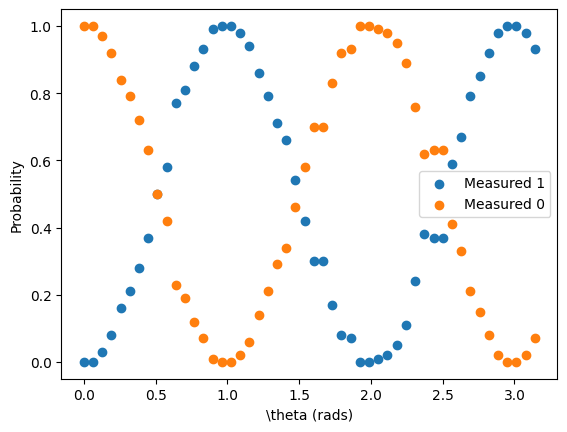

In [154]:
print("Exercise: Rotating qubit. Rabi oscillation")
import sympy as sp

q = cirq.LineQubit(1)



c = cirq.Circuit(cirq.XPowGate(exponent=sp.Symbol('theta'))(q))
c.append(cirq.measure(q, key='m'))

num_theta = 50
param_sweep = cirq.Linspace('theta', start=0, stop=np.pi, length=num_theta)
repetitions = 100

s = cirq.Simulator()
results = s.run_sweep(c, param_sweep, repetitions=100)
#for result in results:
#    np.sum(result) / repetitions
x_data = [result.params['theta'] for result in results]
y1_data = [result.histogram(key='m')[1] / repetitions for result in results]
y0_data = 1 - np.array(y1_data)


plt.scatter('t', 'y1', data={'t':x_data, 'y1':y1_data}, label='Measured 1')
plt.scatter('t', 'y0', data={'t':x_data, 'y0':y0_data}, label='Measured 0')
plt.xlabel(r"\theta (rads)")
plt.ylabel("Probability")
plt.legend()
plt.show()

In [ ]:
import cirq_google

device = cirq_google.Sycamore
print(device)

qubits = []
size_lattice = 3

if size_lattice > 5:
    raise ValueError("Size of the lattice should be less than 5 to fit in the Sycamore")
for j in range(size_lattice):
    for k in range(size_lattice):
        qubits.append(cirq.GridQubit(2 + j, 3 + k))


                                             (0, 5)───(0, 6)
                                             │        │
                                             │        │
                                    (1, 4)───(1, 5)───(1, 6)───(1, 7)
                                    │        │        │        │
                                    │        │        │        │
                           (2, 3)───(2, 4)───(2, 5)───(2, 6)───(2, 7)───(2, 8)
                           │        │        │        │        │        │
                           │        │        │        │        │        │
                  (3, 2)───(3, 3)───(3, 4)───(3, 5)───(3, 6)───(3, 7)───(3, 8)───(3, 9)
                  │        │        │        │        │        │        │        │
                  │        │        │        │        │        │        │        │
         (4, 1)───(4, 2)───(4, 3)───(4, 4)───(4, 5)───(4, 6)───(4, 7)───(4, 8)───(4, 9)
         │        │        │        │        │        │   

In [211]:
c = cirq.Circuit()
for j in range(size_lattice**2 ):
    c.append(cirq.H(qubits[j]))
    c.append(cirq.CZ(qubits[j], qubits[(j+1) % (size_lattice**2)]))

print(c)
try:
    cirq_google.Sycamore.validate_circuit(c)
except ValueError as e:
    print(e)

(2, 3): ───H───@───────────────────────────────────────────────────────────────@───
               │                                                               │
(2, 4): ───────@───H───@───────────────────────────────────────────────────────┼───
                       │                                                       │
(2, 5): ───────────────@───H───@───────────────────────────────────────────────┼───
                               │                                               │
(3, 3): ───────────────────────@───H───@───────────────────────────────────────┼───
                                       │                                       │
(3, 4): ───────────────────────────────@───H───@───────────────────────────────┼───
                                               │                               │
(3, 5): ───────────────────────────────────────@───H───@───────────────────────┼───
                                                       │                       │
(4, 3): ──

In [213]:
# @title Expand to view the solution
class SquareDevice(cirq.Device):
    """A Square Grid Device.

    The device that only allows
        1) Grid Qubits from (0, 0) to (grid_size - 1, grid_size - 1)
        2) H, CZ and MeasurementGate gates.
    """

    def __init__(self, grid_size):
        self.qubits = []
        for i in range(grid_size):
            for j in range(grid_size):
                self.qubits.append(cirq.GridQubit(i, j))

    def validate_operation(self, operation: 'cirq.Operation') -> None:
        if not isinstance(operation, cirq.GateOperation):
            raise ValueError(f"Unsupported operation {operation}")
        if not (
            operation.gate in [cirq.H, cirq.CZ] or isinstance(operation.gate, cirq.MeasurementGate)
        ):
            raise ValueError(f"Unsupported gate {operation.gate}")
        for qubit in operation.qubits:
            if qubit not in self.qubits:
                raise ValueError(f"Qubit {qubit} not on device")

     

In [ ]:
q= cirq.LineQubit.range(2)

c=cirq.Circuit(
    [cirq.H(qs) for qs in q],
    cirq.CNOT(*q),
    [cirq.H(qs) for qs in q]
)
print(c)



0: ───H───@───H───
          │
1: ───H───X───H───


In [218]:
def optimize_circuit(circuit, context=None, k=2):

    #Merge 2qubit connected components into circuit operations
    optimized_circuit = cirq.merge_k_qubit_unitaries(
        circuit, k=k, rewriter=lambda op: op.with_tags("merged"), context=context
    )

    #Drop close to identity op.
    optimized_circuit = cirq.drop_negligible_operations(optimized_circuit, context=context)

    #Decomposing components
    optimized_circuit = cirq.expand_composite(
            optimized_circuit, no_decomp=lambda op: "merged" not in op.tags, context=context
    )

    #Sync measurements to happen at the same moment
    optimized_circuit = cirq.synchronize_terminal_measurements(optimized_circuit, context=context)

    #Assert that circuit and optimized_circuit are the same
    cirq.testing.assert_circuits_with_terminal_measurements_are_equivalent(circuit, optimized_circuit)

    return optimized_circuit


circuit_opt = optimize_circuit(c)
print(circuit_opt)

0: ───H───@───H───
          │
1: ───H───X───H───


In [ ]:
def simplify_flipped_cnots(circuit, *, context=None):
    """Replaces a CX surrounded by Hadamards"""

    def can_merge(ops1, ops2):
        merged = cirq.Circuit(ops1, ops2)
        return (
            len(merged) <= 3
            and all(o.gate == cirq.H for o in merged[0].operations)
            and merged[1].operations[0].gate == cirq.CNOT
            and (len(merged) < 3 or all(o.gate == cirq.H for o in merged[2].operations))
        )

    merged_tag = "h_cx_h"
    circuit = cirq.merge_operations_to_circuit_op(
        circuit, can_merge, merged_circuit_op_tag=merged_tag
    )

    def map_func(op, _):
        if merged_tag not in op.tags:
            return op
        cops = [*op.untagged.mapped_circuit().all_operations()]
        return cirq.CNOT(*cops[2].qubits[::-1]) if len(cops) == 5 else cops

    return cirq.map_operations(circuit, map_func)


print(f"Before optimizing:\n{c}\n")
print(f"After optimizing:\n{simplify_flipped_cnots(c)}")


Before optimizing:
0: ───H───@───H───
          │
1: ───H───X───H───

After optimizing:
0: ───────X───────
          │
1: ───────@───────
